In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [2]:
df = pd.read_csv("../data/cleaned_sp500.csv")

df['Date'] = pd.to_datetime(df['Date'])

df.head()

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume
0,A,2000-01-03,47.07,47.18,40.27,43.04,43.04,4674353
1,A,2000-01-04,40.72,41.17,38.70,39.75,39.75,4765083
2,A,2000-01-05,39.60,39.75,36.05,37.28,37.28,5758642
3,A,2000-01-06,36.83,37.06,34.74,35.86,35.86,2534434
4,A,2000-01-07,35.30,39.41,35.27,38.85,38.85,2819626


In [3]:
apple = df[df['Ticker'] == 'AAPL'].copy()

apple.head()

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume
11705,AAPL,2000-01-03,0.79,0.84,0.76,0.84,0.84,535796800
11706,AAPL,2000-01-04,0.81,0.83,0.76,0.77,0.77,512377600
11707,AAPL,2000-01-05,0.78,0.83,0.77,0.78,0.78,778321600
11708,AAPL,2000-01-06,0.79,0.80,0.71,0.71,0.71,767972800
11709,AAPL,2000-01-07,0.72,0.76,0.72,0.75,0.75,460734400


# Basic Treand Visualization

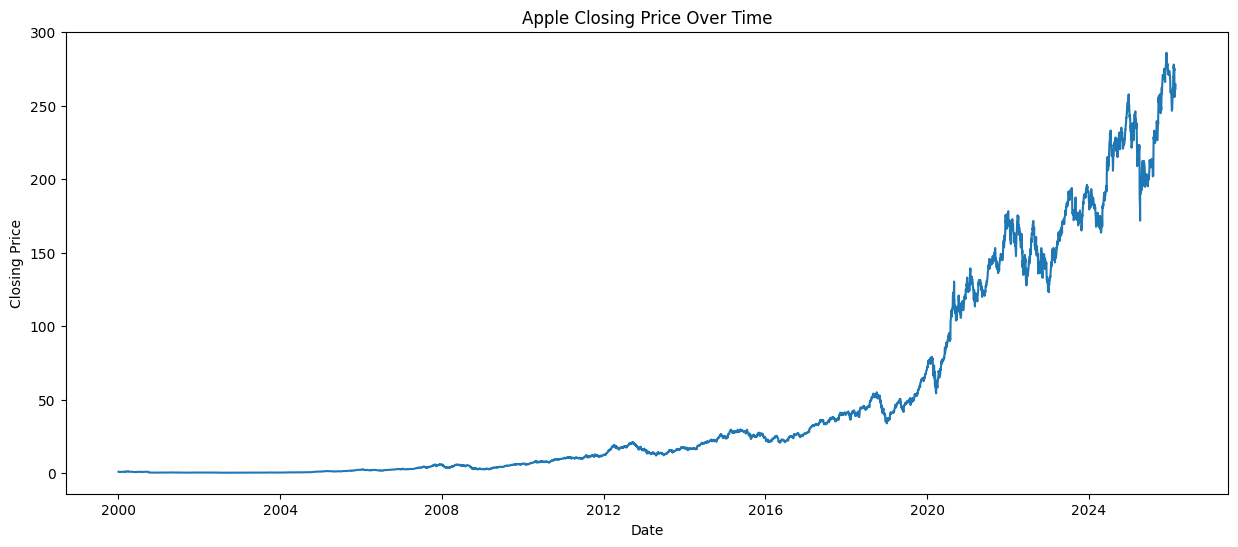

In [4]:
plt.figure(figsize=(15,6))

plt.plot(apple['Date'], apple['Close'])

plt.title("Apple Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.show()

# Interactive Plotly

In [5]:
fig = px.line(
    apple,
    x='Date',
    y='Close',
    title='Apple Stock Price'
)

fig.show()

# Volume Analysis

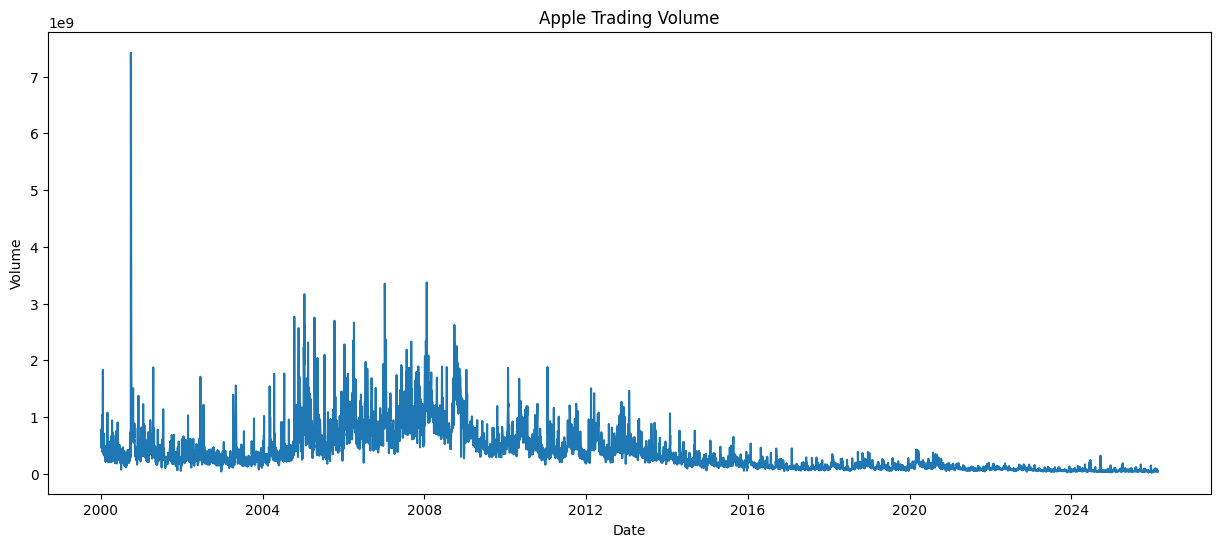

In [6]:
plt.figure(figsize=(15,6))

plt.plot(apple['Date'], apple['Volume'])

plt.title("Apple Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")

plt.show()

# Moving Averages

In [7]:
apple['MA10'] = apple['Close'].rolling(window=10).mean()

apple['MA50'] = apple['Close'].rolling(window=50).mean()

apple['MA200'] = apple['Close'].rolling(window=200).mean()

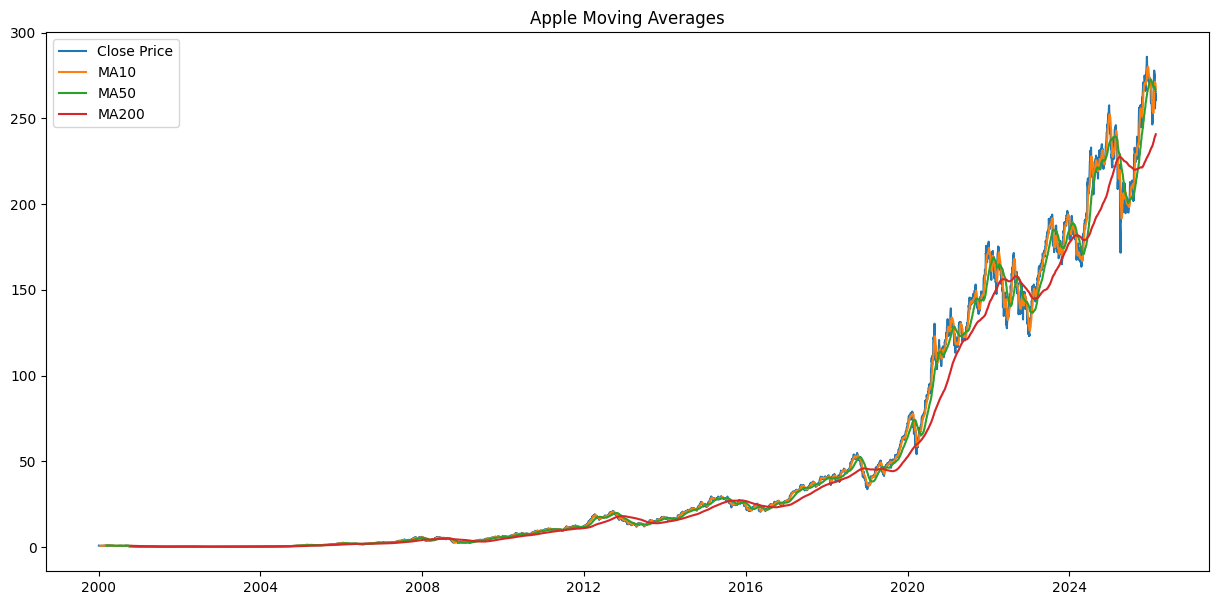

In [8]:
plt.figure(figsize=(15,7))

plt.plot(apple['Date'], apple['Close'], label='Close Price')

plt.plot(apple['Date'], apple['MA10'], label='MA10')

plt.plot(apple['Date'], apple['MA50'], label='MA50')

plt.plot(apple['Date'], apple['MA200'], label='MA200')

plt.legend()

plt.title("Apple Moving Averages")

plt.show()

## Daily Return=​Pt​−Pt−1/Pt−1​​

### Daily Return

In [9]:
apple['Daily_Return'] = apple['Close'].pct_change()

apple.head()

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume,MA10,MA50,MA200,Daily_Return
11705,AAPL,2000-01-03,0.79,0.84,0.76,0.84,0.84,535796800,NaN,NaN,NaN,NaN
11706,AAPL,2000-01-04,0.81,0.83,0.76,0.77,0.77,512377600,NaN,NaN,NaN,-0.083333
11707,AAPL,2000-01-05,0.78,0.83,0.77,0.78,0.78,778321600,NaN,NaN,NaN,0.012987
11708,AAPL,2000-01-06,0.79,0.80,0.71,0.71,0.71,767972800,NaN,NaN,NaN,-0.089744
11709,AAPL,2000-01-07,0.72,0.76,0.72,0.75,0.75,460734400,NaN,NaN,NaN,0.056338


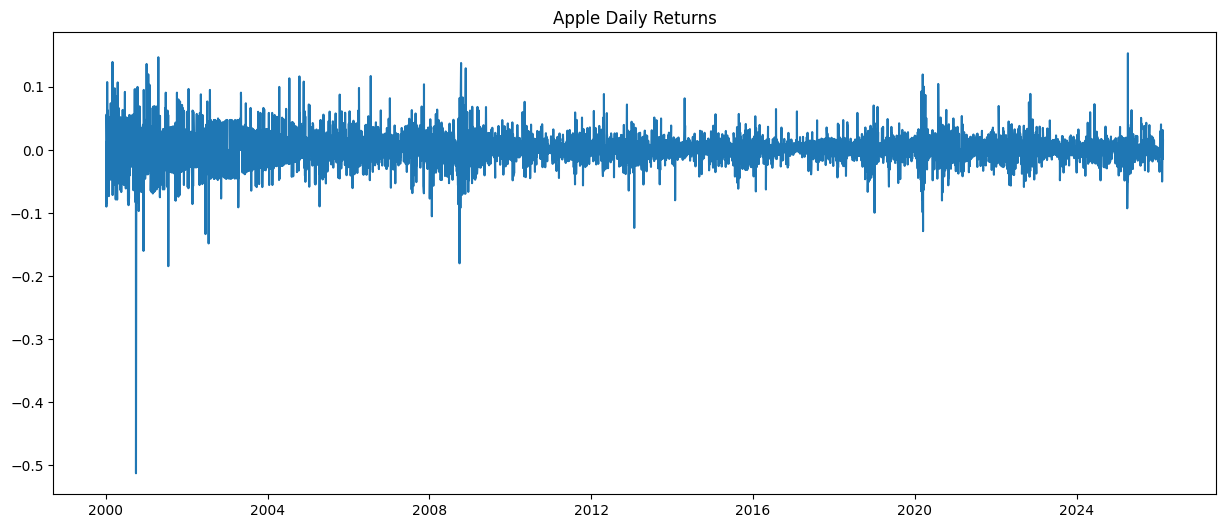

In [10]:
plt.figure(figsize=(15,6))

plt.plot(apple['Date'], apple['Daily_Return'])

plt.title("Apple Daily Returns")

plt.show()

# Volatility Analysis

In [11]:
volatility = apple['Daily_Return'].std()

print("Volatility:", volatility)

Volatility: 0.024884222687970307


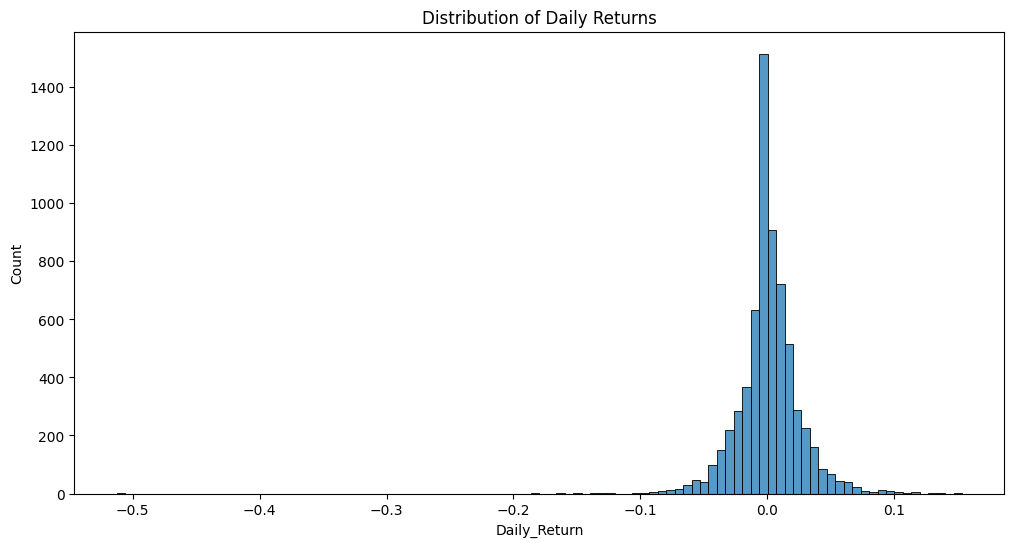

In [12]:
# histogram of returns

plt.figure(figsize=(12,6))

sns.histplot(apple['Daily_Return'].dropna(), bins=100)

plt.title("Distribution of Daily Returns")

plt.show()

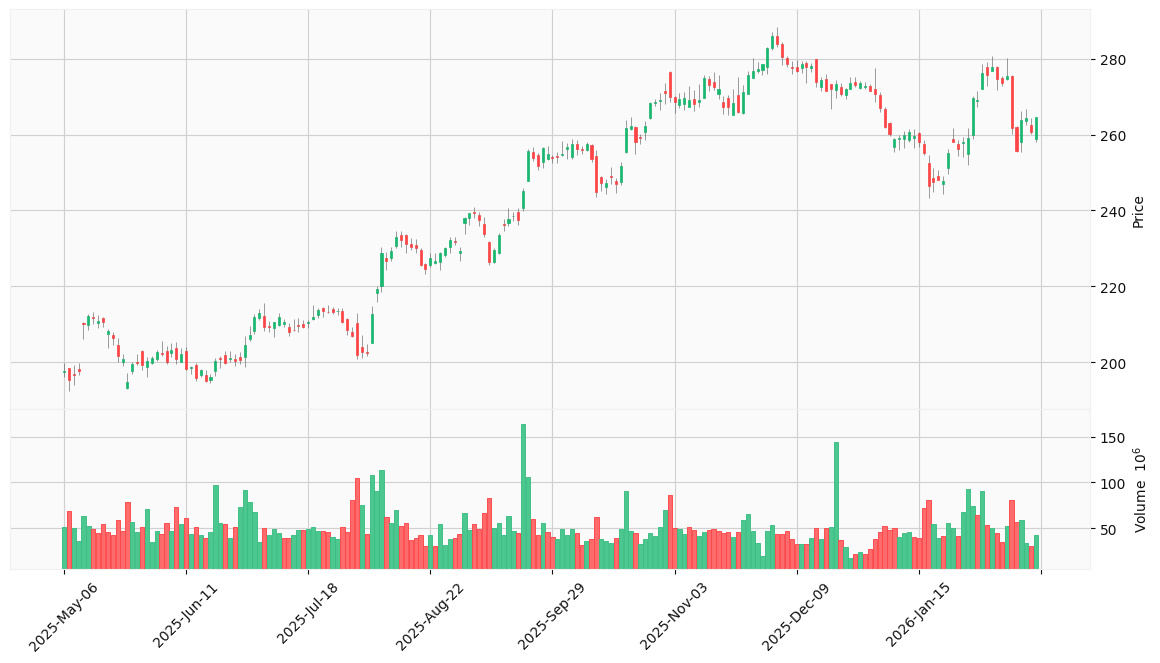

In [13]:
# Candle Stick Visualization 

import mplfinance as mpf

apple2 = apple.set_index('Date')

mpf.plot(
    apple2.tail(200),
    type='candle',
    volume=True,
    style='yahoo',
    figsize=(15,8)
)

# Correlation Between Stocks
Used: AAPL,MSFT,NVDA,PG

In [14]:
stocks = df[df['Ticker'].isin(['AAPL', 'MSFT', 'NVDA', 'PG'])]

### Pivot Table

In [15]:
pivot = stocks.pivot(
    index='Date',
    columns='Ticker',
    values='Close'
)

pivot.head()

Ticker,AAPL,MSFT,NVDA,PG
Date,,,,
2000-01-03,0.84,35.60,0.09,26.83
2000-01-04,0.77,34.40,0.09,26.32
2000-01-05,0.78,34.76,0.08,25.82
2000-01-06,0.71,33.60,0.08,27.01
2000-01-07,0.75,34.04,0.08,29.17


### Correlation matrix

In [16]:
corr = pivot.corr()

corr

Ticker,AAPL,MSFT,NVDA,PG
Ticker,,,,
AAPL,1.000000,0.987972,0.843978,0.953792
MSFT,0.987972,1.000000,0.864917,0.942787
NVDA,0.843978,0.864917,1.000000,0.716840
PG,0.953792,0.942787,0.716840,1.000000


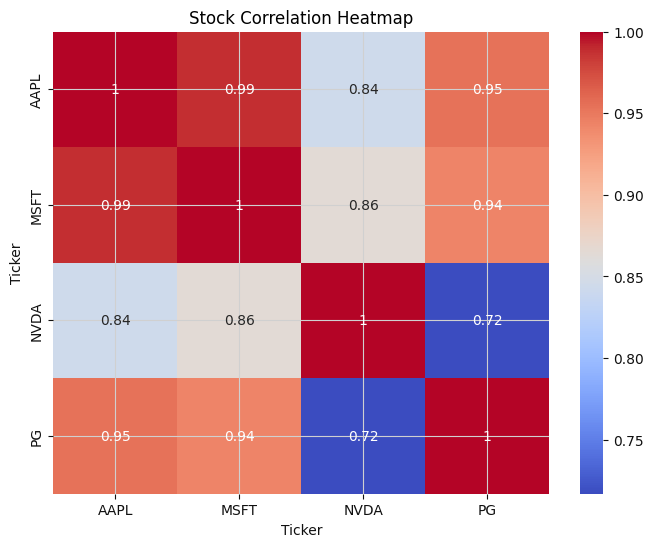

In [17]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Stock Correlation Heatmap")

plt.show()

# High performance Stocks

In [18]:
latest_prices = df.groupby('Ticker')['Close'].last()

first_prices = df.groupby('Ticker')['Close'].first()

returns = ((latest_prices - first_prices) / first_prices) * 100

returns.sort_values(ascending=False).head(10)

Ticker
NVDA    210811.111111
MNST    209300.000000
AXON     94228.260870
DECK     79026.666667
TPL      75639.393939
NFLX     65458.333333
ODFL     42748.936170
TSCO     33000.000000
AAPL     31397.619048
AVGO     29079.824561
Name: Close, dtype: float64

In [19]:
apple.to_csv("../data/apple_processed.csv", index=False)